# ASSIGNMENT 10
## Comparing GAN and VAE Using Our Own Experimental Results

**Name:** Keerthi N  
**Registration Number:** 2411021240024  
**Course:** Generative AI

## Objective

The objective of this assignment is to compare a GAN and a VAE using practical experimental results rather than only theoretical knowledge.

## Previous Assignments Used

- Assignment 4: Deep Convolutional Generative Adversarial Network (DCGAN) trained on the Fashion-MNIST dataset for 25 epochs.
- Assignment 8: Variational Autoencoder (VAE) trained on the MNIST handwritten digit dataset for 20 epochs.

Approximately eight generated images from each model will be selected and compared based on image sharpness, diversity, realism, training stability, ease of controlling the output, risk of mode collapse, and typical applications.

In [1]:
# Assignment 10: Upload the original Assignment 4 and Assignment 8 notebooks

from google.colab import files

print("Upload your Assignment 4 DCGAN notebook.")
uploaded_gan = files.upload()

print("\nUpload your Assignment 8 VAE notebook.")
uploaded_vae = files.upload()

# Find the uploaded notebook filenames
gan_files = [
    name for name in uploaded_gan
    if name.lower().endswith(".ipynb")
    and "assignment_4" in name.lower()
]

vae_files = [
    name for name in uploaded_vae
    if name.lower().endswith(".ipynb")
    and "assignment_8" in name.lower()
]

if not gan_files or not vae_files:
    raise ValueError(
        "Could not identify both notebooks. "
        "Check that you uploaded the Assignment 4 and Assignment 8 .ipynb files."
    )

gan_notebook_path = gan_files[0]
vae_notebook_path = vae_files[0]

print("\nGAN notebook:", gan_notebook_path)
print("VAE notebook:", vae_notebook_path)
print("\nBoth notebook files are ready for Assignment 10.")

Upload your Assignment 4 DCGAN notebook.


Saving Assignment_4_DCGAN_Fashion_MNIST (1).ipynb to Assignment_4_DCGAN_Fashion_MNIST (1).ipynb

Upload your Assignment 8 VAE notebook.


Saving Assignment_8_Variational_Autoencoder_MNIST (1).ipynb to Assignment_8_Variational_Autoencoder_MNIST (1).ipynb

GAN notebook: Assignment_4_DCGAN_Fashion_MNIST (1).ipynb
VAE notebook: Assignment_8_Variational_Autoencoder_MNIST (1).ipynb

Both notebook files are ready for Assignment 10.


In [2]:
# Extract the saved GAN and VAE image grids from the notebook files

import json
import base64
from pathlib import Path

def extract_saved_plot(notebook_path, source_keyword, output_path):
    with open(notebook_path, "r", encoding="utf-8") as f:
        notebook = json.load(f)

    for cell in notebook.get("cells", []):
        source = "".join(cell.get("source", []))

        if source_keyword not in source:
            continue

        for output in cell.get("outputs", []):
            data = output.get("data", {})
            png_data = data.get("image/png")

            if png_data:
                # Notebook image data can be one string or a list of strings
                if isinstance(png_data, list):
                    png_data = "".join(png_data)

                image_bytes = base64.b64decode(png_data)

                with open(output_path, "wb") as f:
                    f.write(image_bytes)

                print("Extracted image:", output_path)
                return output_path

    raise ValueError(
        f"No saved PNG output found for '{source_keyword}'. "
        "The notebook may not contain a saved output for that cell."
    )

# Extract the final 4 x 4 GAN image grid from Assignment 4
gan_grid_path = extract_saved_plot(
    gan_notebook_path,
    "final_noise =",
    "GAN_original_grid.png"
)

# Extract the 20 random-latent-point VAE image grid from Assignment 8
vae_grid_path = extract_saved_plot(
    vae_notebook_path,
    "num_new_images = 20",
    "VAE_original_grid.png"
)

print("\nBoth generated-image grids have been extracted.")

Extracted image: GAN_original_grid.png
Extracted image: VAE_original_grid.png

Both generated-image grids have been extracted.


Assignment 4: Final GAN-generated images


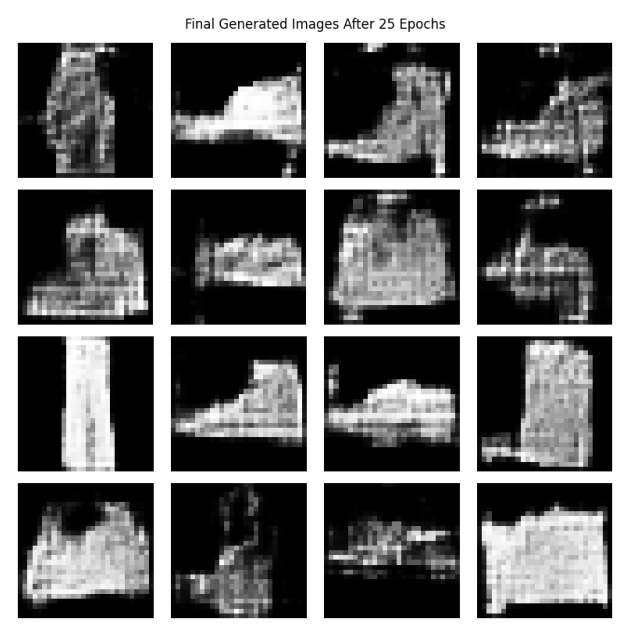

Assignment 8: VAE-generated digits from random latent points


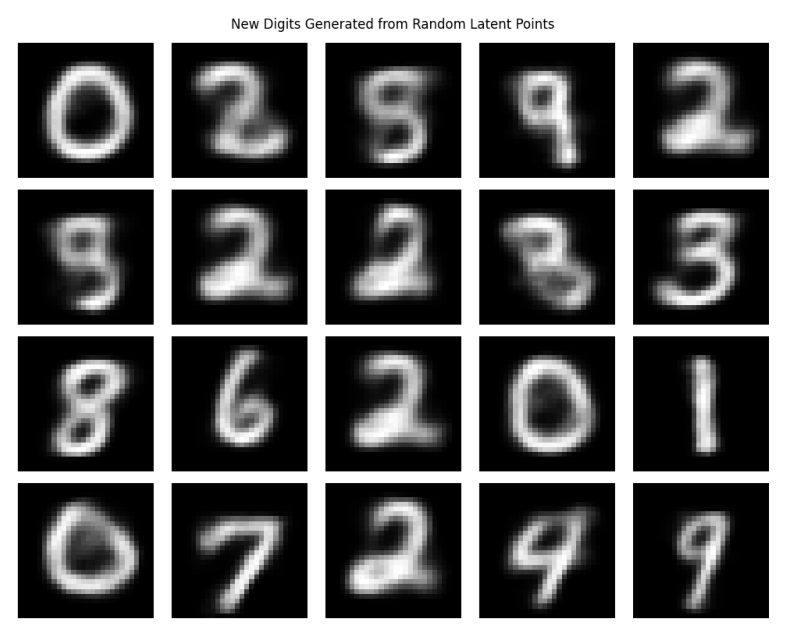

In [3]:
# Display the original saved outputs from both assignments

from PIL import Image
import matplotlib.pyplot as plt

gan_grid = Image.open(gan_grid_path).convert("RGB")
vae_grid = Image.open(vae_grid_path).convert("RGB")

print("Assignment 4: Final GAN-generated images")
plt.figure(figsize=(8, 8))
plt.imshow(gan_grid)
plt.axis("off")
plt.show()

print("Assignment 8: VAE-generated digits from random latent points")
plt.figure(figsize=(10, 8))
plt.imshow(vae_grid)
plt.axis("off")
plt.show()

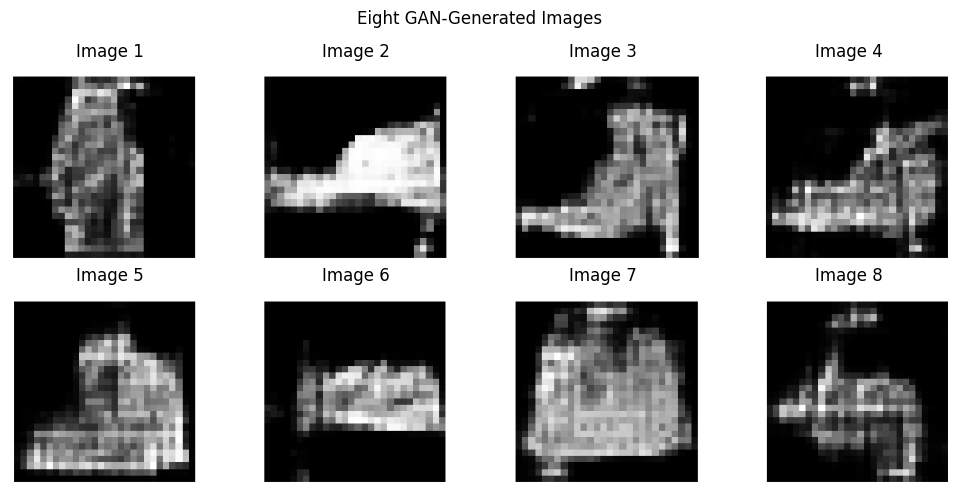

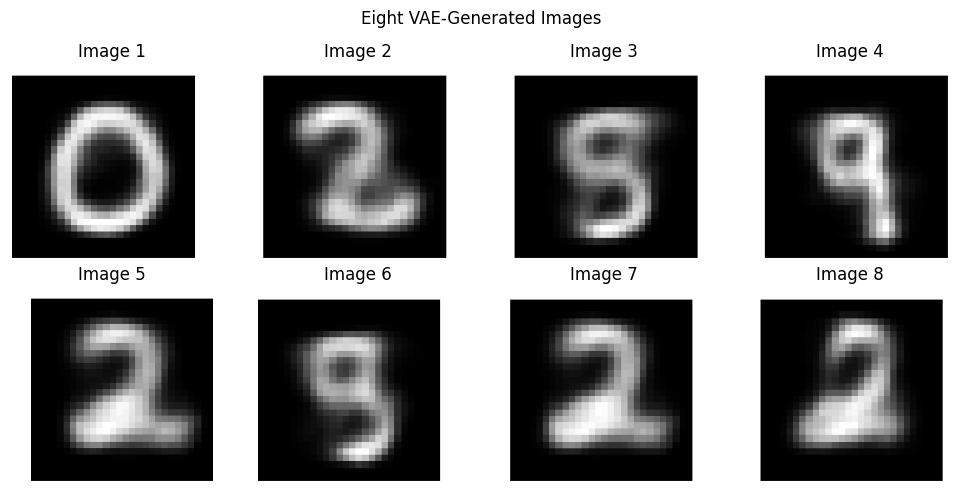

Saved both eight-image sheets.


In [4]:
# Select approximately 8 images from each original output grid

from PIL import Image
import matplotlib.pyplot as plt

def crop_grid_images(image, rows, cols, count=8):
    width, height = image.size

    # Remove the heading area and outer margins approximately
    left = int(width * 0.01)
    right = int(width * 0.99)
    top = int(height * 0.04)
    bottom = int(height * 0.99)

    grid = image.crop((left, top, right, bottom))
    grid_width, grid_height = grid.size

    tile_width = grid_width / cols
    tile_height = grid_height / rows

    selected = []

    for i in range(count):
        row = i // cols
        col = i % cols

        x1 = int(col * tile_width)
        y1 = int(row * tile_height)
        x2 = int((col + 1) * tile_width)
        y2 = int((row + 1) * tile_height)

        selected.append(
            grid.crop((x1, y1, x2, y2))
        )

    return selected

gan_selected = crop_grid_images(
    gan_grid, rows=4, cols=4, count=8
)

vae_selected = crop_grid_images(
    vae_grid, rows=4, cols=5, count=8
)

def display_and_save_sheet(images, title, filename):
    fig, axes = plt.subplots(2, 4, figsize=(10, 5))

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(f"Image {i + 1}")
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

display_and_save_sheet(
    gan_selected,
    "Eight GAN-Generated Images",
    "GAN_selected_8_images.png"
)

display_and_save_sheet(
    vae_selected,
    "Eight VAE-Generated Images",
    "VAE_selected_8_images.png"
)

print("Saved both eight-image sheets.")

## Generated Images Selected for Comparison

### GAN-Generated Images — Assignment 4

The DCGAN was trained on Fashion-MNIST for 25 epochs. Eight images have been selected from its final generated-image grid. The images are used to examine sharpness, diversity, and how closely the generated shapes resemble clothing items.

### VAE-Generated Images — Assignment 8

The VAE was trained on MNIST for 20 epochs. Eight images have been selected from its grid of 20 images generated from random latent points. The images are used to examine the clarity, diversity, and recognizability of generated handwritten digits.

GAN: Eight selected images from Assignment 4


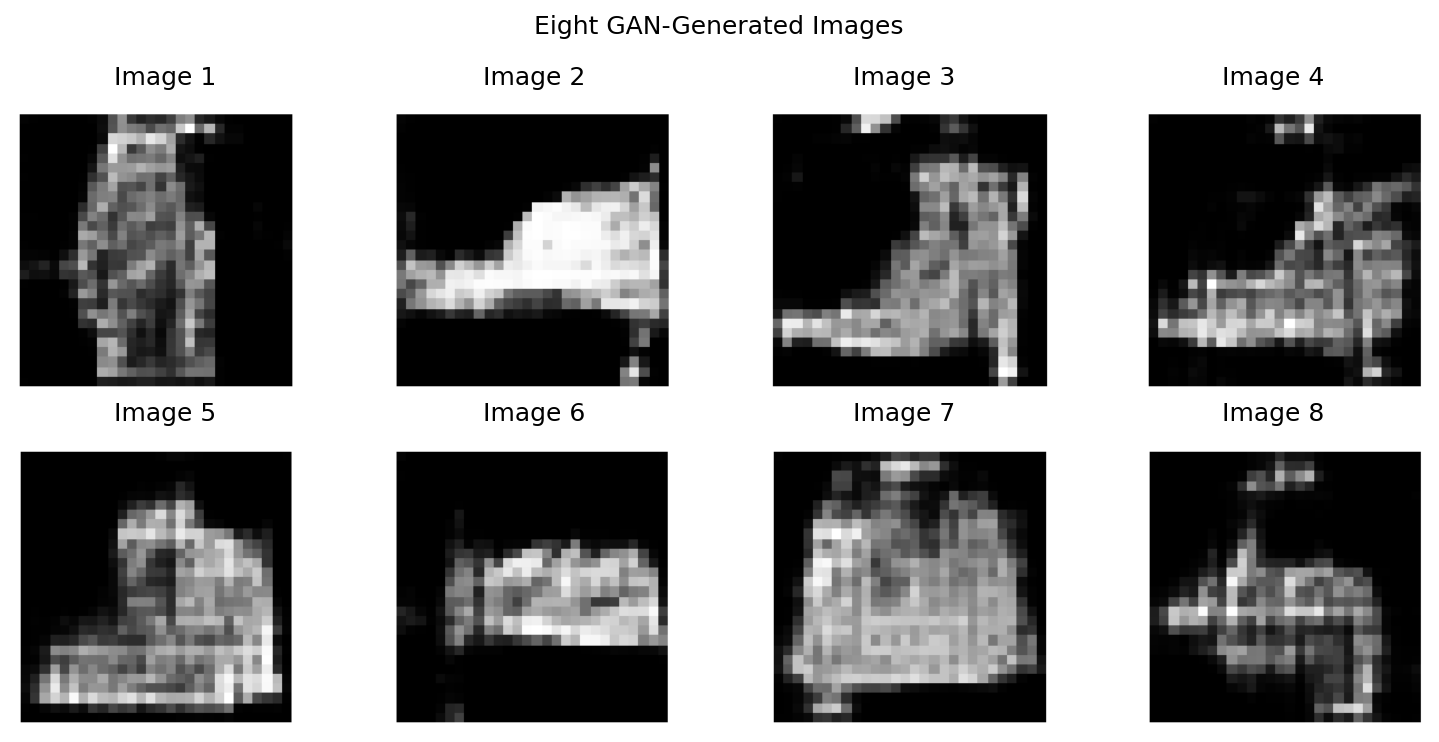

VAE: Eight selected images from Assignment 8


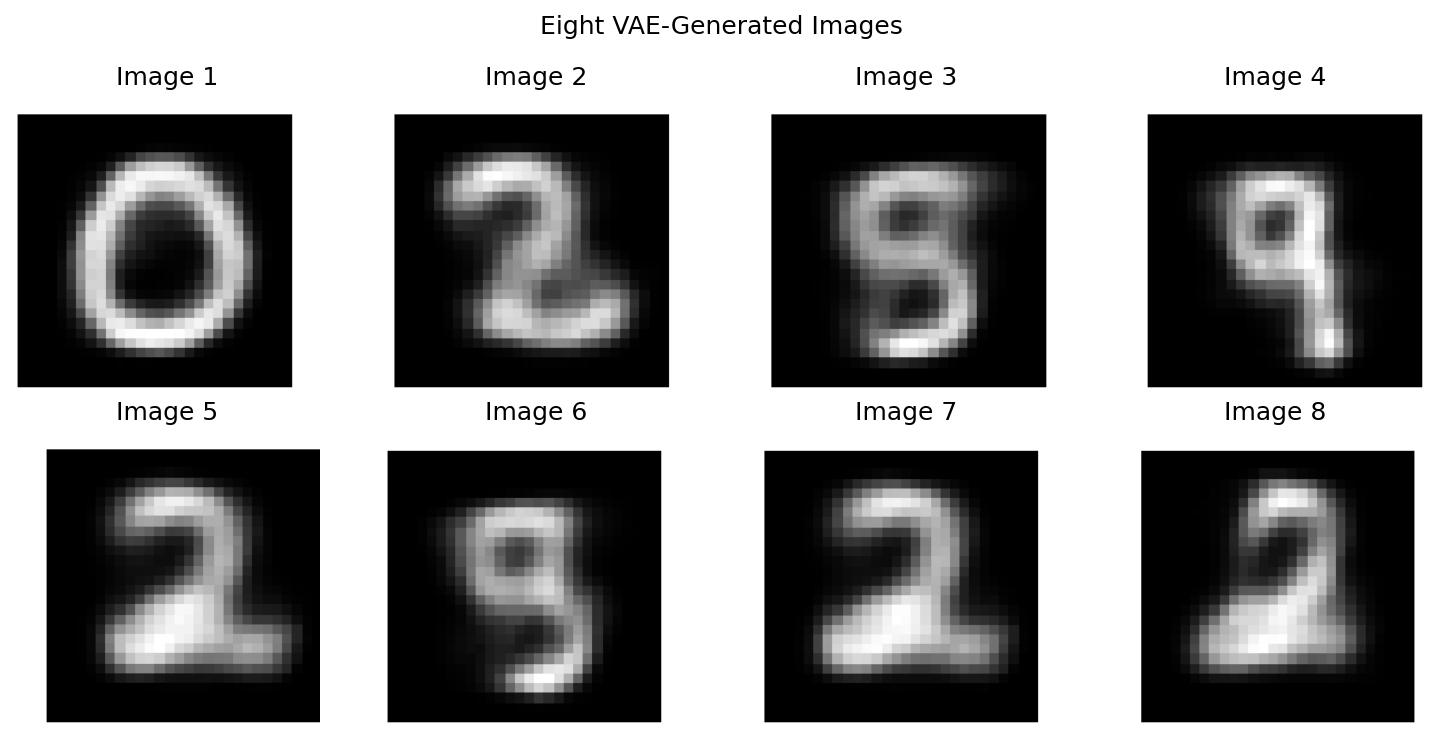

In [5]:
# Display the final selected image sheets

from IPython.display import display

print("GAN: Eight selected images from Assignment 4")
display(Image.open("GAN_selected_8_images.png"))

print("VAE: Eight selected images from Assignment 8")
display(Image.open("VAE_selected_8_images.png"))

## Comparison Table

The GAN and VAE are compared using the seven criteria specified in Assignment 10. The comparison uses the saved generated-image outputs and the training observations documented in Assignments 4 and 8.

The models use different datasets: Fashion-MNIST for the GAN and MNIST for the VAE. Therefore, the comparison considers each model's generated images within its own task rather than treating the images as if they belonged to the same dataset.

In [6]:
import pandas as pd
from IPython.display import display

comparison_data = {
    "Criterion": [
        "Image sharpness",
        "Diversity",
        "Realism",
        "Training stability",
        "Ease of controlling the output",
        "Risk of mode collapse",
        "Typical applications"
    ],

    "GAN - Assignment 4": [
        "The generated clothing-like images have visible shapes, but some details are blurry or distorted.",
        "The 16-image grid contains different clothing-like shapes. Check whether any outputs are repeated or very similar.",
        "Some images resemble clothing items, but the outputs are not all clearly recognizable.",
        "The Assignment 4 analysis reports fluctuations in generator and discriminator losses during training.",
        "Random noise is supplied to the generator. Direct control over a specific clothing category is limited.",
        "GANs can suffer from mode collapse, in which many outputs become similar. Inspect the generated grid for evidence.",
        "Synthetic image generation and realistic image synthesis."
    ],

    "VAE - Assignment 8": [
        "The generated digits have smooth shapes, although some edges may be blurry.",
        "The 20-image grid contains different handwritten digit shapes. Check for repeated digit types.",
        "Many generated images resemble handwritten digits, although some may be unclear.",
        "The VAE is trained using reconstruction and KL divergence losses. Review its recorded loss curves when evaluating stability.",
        "The two-dimensional latent space allows exploration of how generated digits change across latent points.",
        "The VAE does not have the same typical adversarial mode-collapse problem as a GAN, although diversity can still be limited.",
        "Image reconstruction, latent-space learning, image generation, and reconstruction-based anomaly detection."
    ]
}

comparison_table = pd.DataFrame(comparison_data)

display(comparison_table)

# Save a copy of the table as a CSV file
comparison_table.to_csv(
    "Assignment_10_Comparison_Table.csv",
    index=False
)

print("Comparison table created and saved as a CSV file.")

,Criterion,GAN - Assignment 4,VAE - Assignment 8
0,Image sharpness,The generated clothing-like images have visibl...,"The generated digits have smooth shapes, altho..."
1,Diversity,The 16-image grid contains different clothing-...,The 20-image grid contains different handwritt...
2,Realism,"Some images resemble clothing items, but the o...",Many generated images resemble handwritten dig...
3,Training stability,The Assignment 4 analysis reports fluctuations...,The VAE is trained using reconstruction and KL...
4,Ease of controlling the output,Random noise is supplied to the generator. Dir...,The two-dimensional latent space allows explor...
5,Risk of mode collapse,"GANs can suffer from mode collapse, in which m...",The VAE does not have the same typical adversa...
6,Typical applications,Synthetic image generation and realistic image...,"Image reconstruction, latent-space learning, i..."


Comparison table created and saved as a CSV file.


## Final Verdict

### 1. Which model would you prefer for generating synthetic training data?

I would prefer the GAN for generating synthetic training data when the main objective is to produce realistic images. In Assignment 4, the DCGAN learned to generate clothing-like images using Fashion-MNIST. The quality of the generated images depends on the training process and how well the generator learns the patterns in the dataset.

### 2. Which model would you prefer for anomaly detection?

I would prefer the VAE for reconstruction-based anomaly detection. In Assignment 8, the VAE learned a latent representation of handwritten digits and generated images using its decoder. Reconstruction error can help identify unusual inputs that the model does not reconstruct well. However, this assignment does not include a separate experiment testing anomaly detection, so this is a model-based preference rather than a demonstrated result.

### 3. Why?

The GAN and VAE have different strengths. A GAN uses a generator and discriminator that compete during training to produce realistic images. A VAE learns a structured latent representation and uses a decoder to reconstruct or generate images.

Therefore, I would choose the GAN for realistic synthetic image generation and the VAE for reconstruction-based anomaly detection. The final choice depends on the application and the quality of the experimental results.

## Conclusion

In this assignment, the GAN from Assignment 4 and the VAE from Assignment 8 were compared using their previously generated images.

The DCGAN was trained on Fashion-MNIST for 25 epochs and generated clothing-like images. The VAE was trained on MNIST for 20 epochs and generated handwritten digits from random points in its two-dimensional latent space.

The comparison covered image sharpness, diversity, realism, training stability, ease of controlling the output, risk of mode collapse, and typical applications.

The experiments illustrate that GANs are useful for synthetic image generation, while VAEs provide a structured latent representation and support image reconstruction. The preferred model depends on the objective and the results obtained from the experiment.